In [ ]:
#check GPU
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Available:  1


## **Loading The Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob as gb
import cv2
from tqdm import tqdm
import tensorflow as tf

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#data path
train_dir='/content/drive/MyDrive/SkinLesion/train/'
test_dir='/content/drive/MyDrive/SkinLesion/test/'

In [ ]:
os.listdir(train_dir)

['benign', 'malignant']

In [ ]:
for folder in  os.listdir(train_dir) :
    print( 'folder name is : ', train_dir+folder)

folder name is :  /content/drive/MyDrive/SkinLesion/train/benign
folder name is :  /content/drive/MyDrive/SkinLesion/train/malignant


In [ ]:
gb.glob(pathname= str( train_dir  + folder + '/*.jpg'))

['/content/drive/MyDrive/SkinLesion/train/malignant/1281.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1108.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/121.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1239.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/117.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1145.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1168.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1106.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1122.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1204.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1133.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1152.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1129.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/131.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1181.jpg',
 '/content/drive/MyDrive/SkinLesion/train/malignant/1124.j

In [ ]:
#loading data and resize it and collect it in one folder
new_size=224
X_train = []
y_train = []
for folder in  os.listdir(train_dir):
    print('folder name is : ', folder)
    # 1
    files = gb.glob(pathname= str( train_dir  + folder + '/*.jpg'))
    # 2
    print( 'numbers of images in folder are : ', len(files))
    print(' start reading images')
    for file in tqdm(files):
        # 3
        image_class = {'benign': 0, 'malignant': 1 }
        orignal_image = cv2.imread(file)
        image = cv2.cvtColor(orignal_image, cv2.COLOR_BGR2RGB)
        #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        resized_image = cv2.resize(image , (new_size,new_size))
        X_train.append(resized_image)
        y_train.append(image_class[folder])
    print('image reading ...finished')
print('--------------------------------------------------')
#check items in X_test
print("items in X_train is:       ",len(X_train) , " items")
print("items in y_train is:       ",len(y_train) , " items")

folder name is :  benign
numbers of images in folder are :  1440
 start reading images


100%|██████████| 1440/1440 [00:15<00:00, 92.35it/s] 


image reading ...finished
folder name is :  malignant
numbers of images in folder are :  1197
 start reading images


100%|██████████| 1197/1197 [01:13<00:00, 16.26it/s] 

image reading ...finished
--------------------------------------------------
items in X_train is:        2637  items
items in y_train is:        2637  items


In [ ]:
np.random.randint(0,len(X_train),16)

array([2187, 1464,  955, 2612, 2442, 1727,  585, 2436, 2112,  176, 2243,
       2485,   87,  109, 2335,  965])

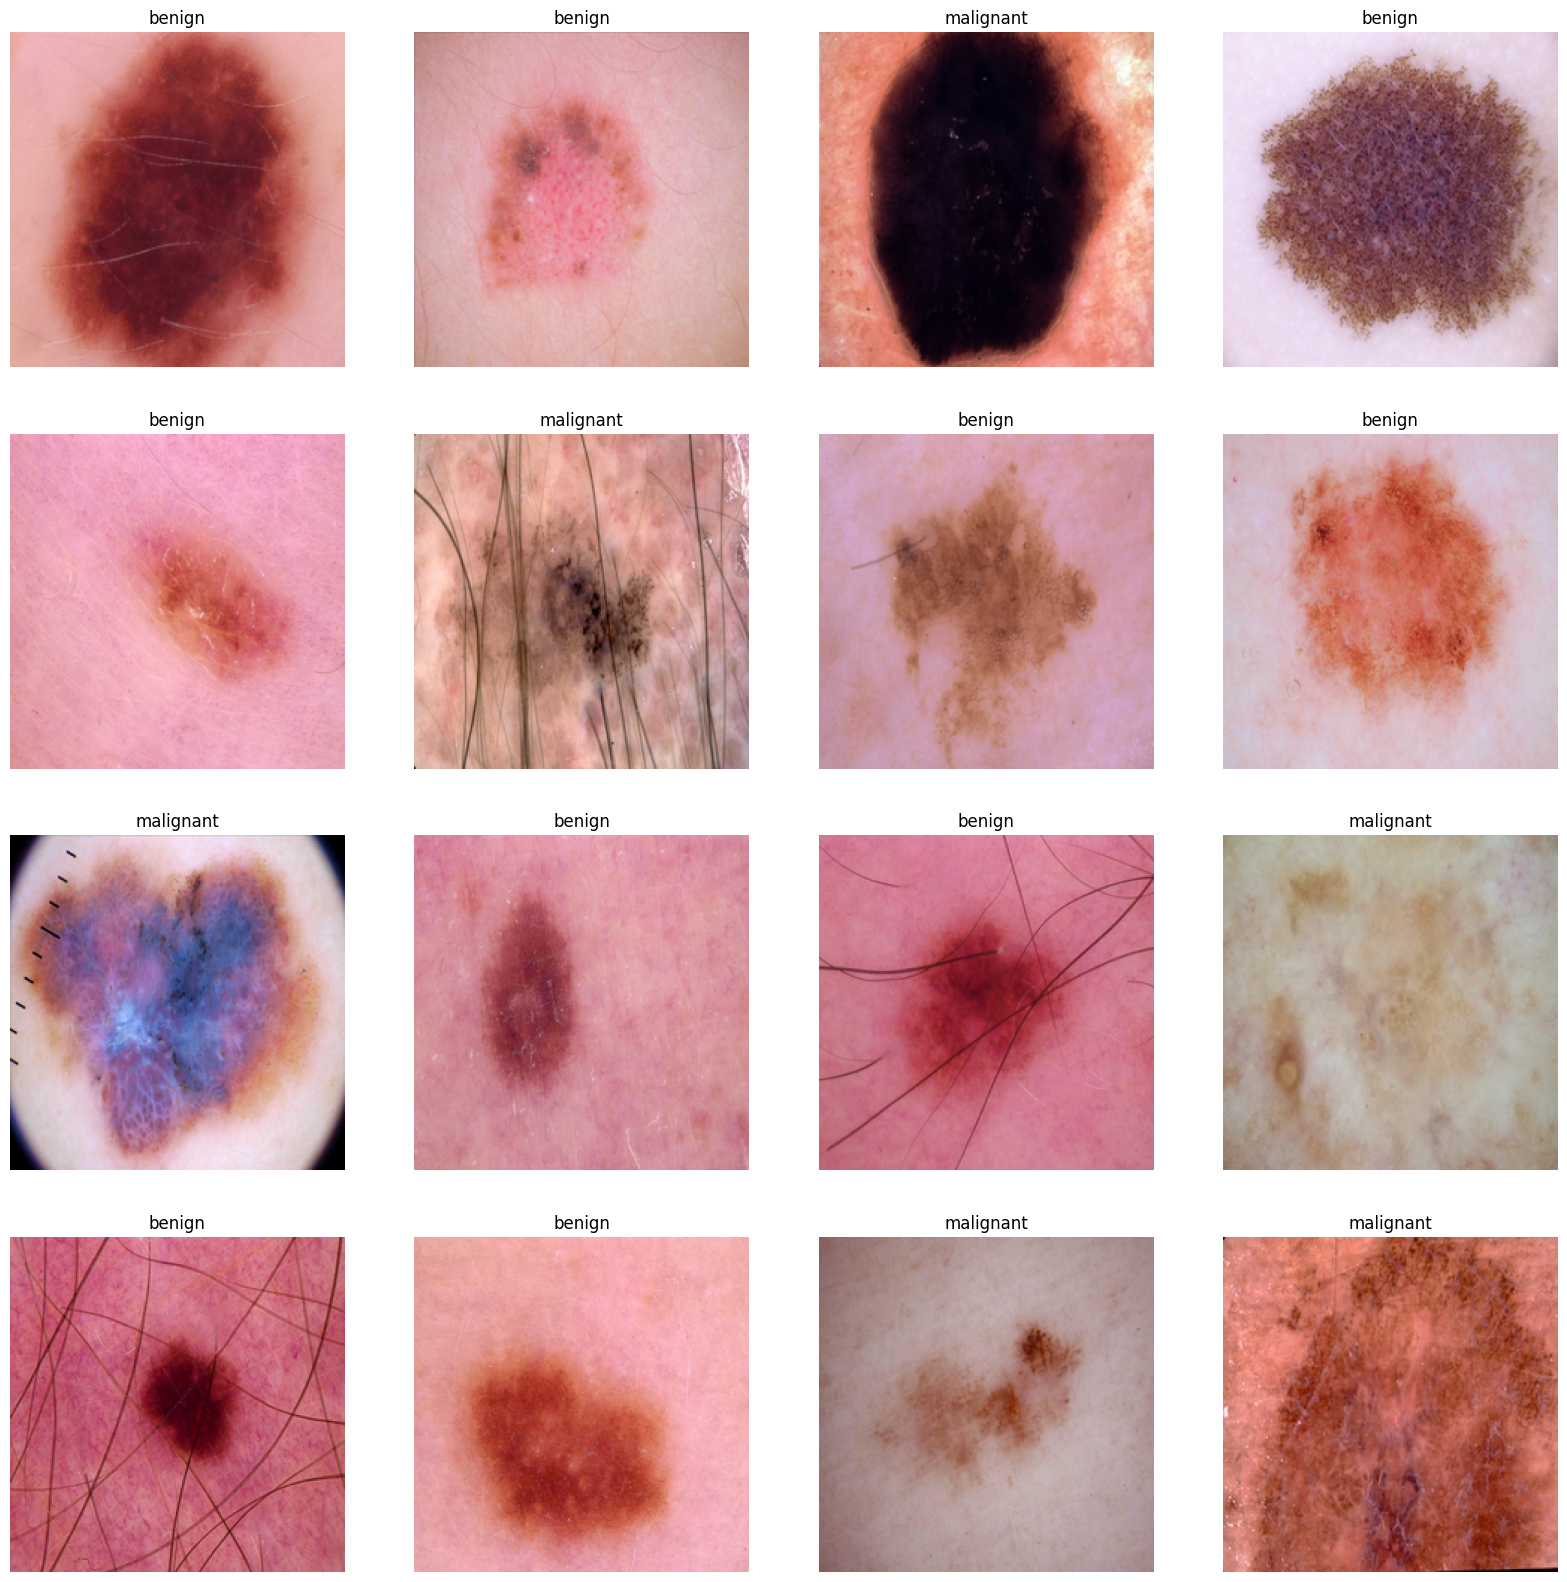

In [ ]:
#showing training images with labels
plt.figure(figsize=(20,20))
for n , i in enumerate(list(np.random.randint(0,len(X_train ),16))) :
    plt.subplot(4,4,n+1)
    plt.imshow(X_train[i]) #,cmap='gray')
    plt.axis('off')
    classes = {'benign': 0, 'malignant': 1 }
    def ImageClass(n):
        for x , y in classes.items():
            if n == y :
                return x
    plt.title(ImageClass(y_train[i]))

In [ ]:
#converting all TRAIN data to array
X_train = np.array(X_train)
X_train= X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 3)
y_train = np.array(y_train)
print("X_train shape  :" ,X_train.shape)
print("y_train shape :", y_train.shape)

X_train shape  : (2637, 224, 224, 3)
y_train shape : (2637,)


In [ ]:
label_1=(y_train==1).sum()
label_1

np.int64(1197)

In [ ]:
label_2=(y_train==0).sum()
label_2

np.int64(1440)

/tmp/ipython-input-3498132373.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


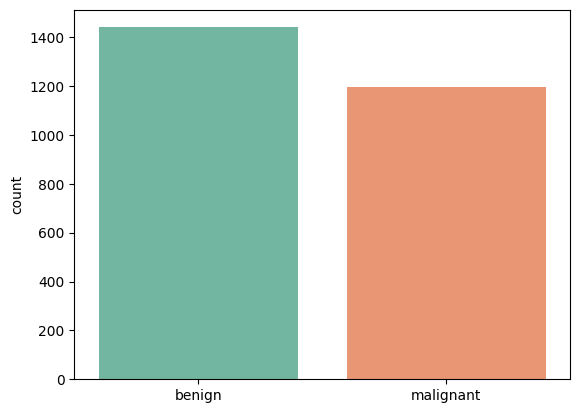

In [ ]:

sns.countplot(x=y_train, palette="Set2")
plt.xticks(ticks=[0, 1], labels=['benign', 'malignant'])
plt.show()

In [ ]:
#shuffle data
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1,
                                                    random_state=4,stratify=y_train)

In [ ]:
#normalizing data
X_train=X_train/255.0
X_test=X_test/255.0

# **CNN**

## Activation function


Reducing Dense layer size decreases model capacity, preventing memorization and improving generalization on small datasets.

In [ ]:
# Creating the model using the Sequential API
from tensorflow import keras
import tensorflow as tf
model = keras.models.Sequential()

model.add(keras.layers.Conv2D(filters=64, kernel_size=7, strides=1,
                padding="same", activation=tf.keras.activations.relu, name="Conv1", input_shape= (224,224,3)))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool1"))
model.add(keras.layers.Conv2D(filters=128, kernel_size=5, strides=1,
                              padding="same", activation="relu", name="Conv2"))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool2"))
model.add(keras.layers.Conv2D(filters=256, kernel_size=3, strides=1,
                              padding="same", activation="relu", name="Conv3"))
model.add(keras.layers.Dropout(0.25))
model.add(keras.layers.MaxPool2D(pool_size=2, name="Pool3"))

model.add(keras.layers.Flatten(name="Flatten1"))
model.add(keras.layers.Dense(128, activation="relu", name="Dense1"))

model.add(keras.layers.Dense(64, activation="relu", name="Dense2"))

model.add(keras.layers.Dense(1, activation="sigmoid", name="Output"))

# The model’s summary() method displays all the model’s layers
print(model.summary())


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 224, 224, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 112, 112, 128)  │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten1 (Flatten)              │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,208,129 (99.98 MB)

 Trainable params: 26,208,129 (99.98 MB)

 Non-trainable params: 0 (0.00 B)

None


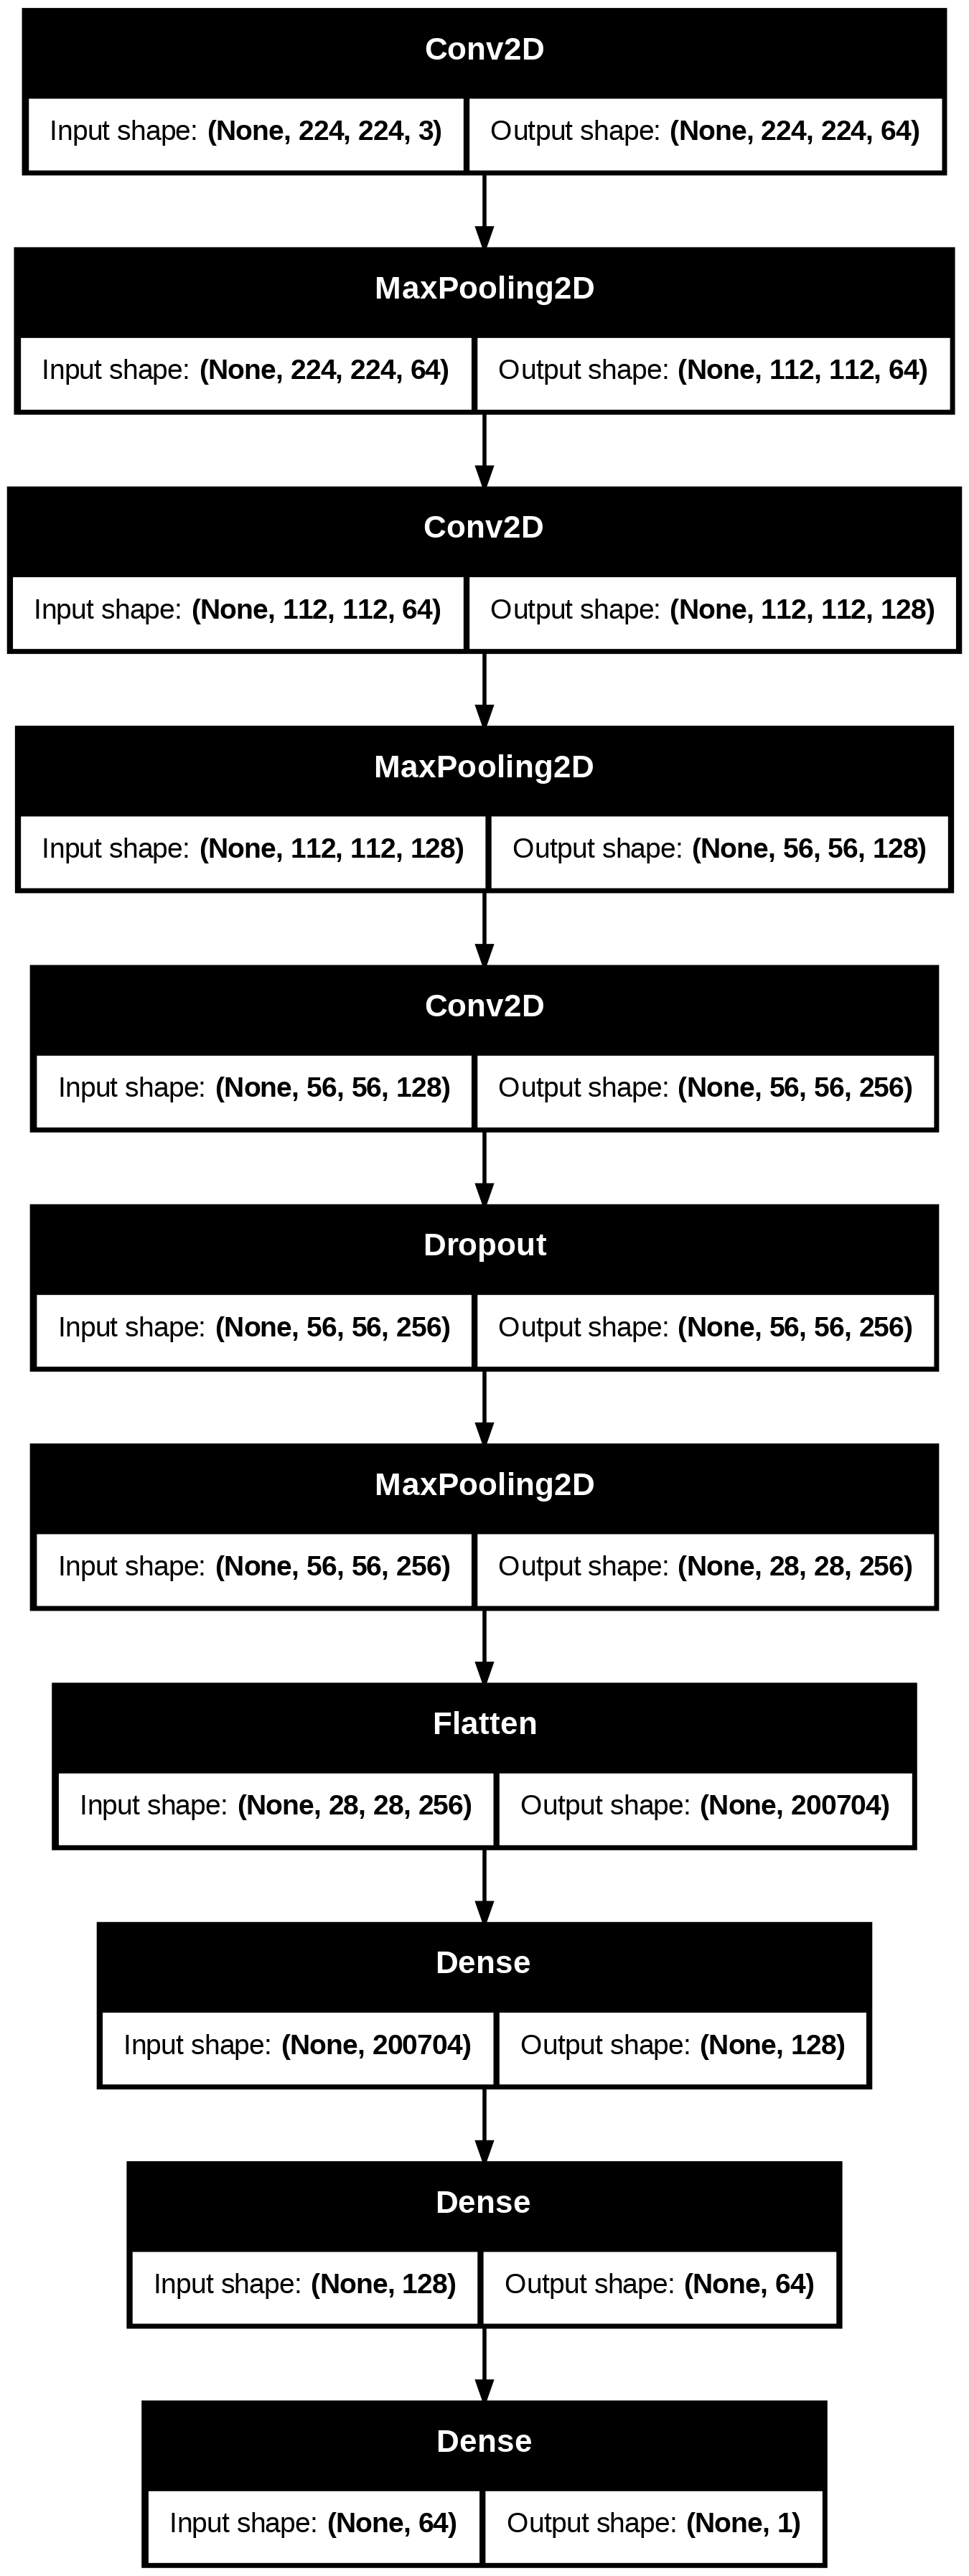

In [ ]:
# Plot the model
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)


## Optimization






## Loss Function
**Regression**

**Binary CLassification**


**Multi Classification**





## Metrics
**Regression**

**Classification**


In [ ]:
# Compiling the model
model.compile(loss="binary_crossentropy", optimizer= 'Adam', metrics=["accuracy","precision","recall"])

Early stopping monitors a validation metric (usually val_loss):
After each epoch, it checks:

Did validation loss improve?

If no improvement for a number of epochs → training stops automatically

So the model stops at the best point, not the last epoch.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Factor by which the learning rate will be reduced. new_lr = lr * factor
    patience=3,          # Number of epochs with no improvement after which learning rate will be reduced.
    min_lr=0.00001,      # Lower bound on the learning rate.
    verbose=1
)

## Train Model
**history = model.fit(X_train, y_train,**

**epochs=30,**

**steps_per_epoch=,**

**batch_size=16,**

**shuffle=True,**

**validation_data=(X_valid,y_valid) or validation_split=0 :1,**

**validation_batch_size=,**

**validation_steps=)**


In [ ]:
# Training the model
history = model.fit(X_train, y_train, epochs=30, batch_size=16,validation_split=0.1,shuffle=True)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.5231 - loss: 0.9703 - precision: 0.4628 - recall: 0.2794 - val_accuracy: 0.5840 - val_loss: 0.6817 - val_precision: 1.0000 - val_recall: 0.0294
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.5640 - loss: 0.7148 - precision: 0.6063 - recall: 0.2127 - val_accuracy: 0.5756 - val_loss: 0.6787 - val_precision: 1.0000 - val_recall: 0.0098
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.5622 - loss: 0.6821 - precision: 0.4008 - recall: 0.0962 - val_accuracy: 0.6471 - val_loss: 0.6512 - val_precision: 0.8000 - val_recall: 0.2353
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.5507 - loss: 0.6910 - precision: 0.5300 - recall: 0.3637 - val_accuracy: 0.5882 - val_loss: 0.6873 - val_precision: 0.6429 - val_recall: 0.0882
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.5687 - loss: 0.6751 - precision: 0.6687 - recall: 0.1460 - val_accuracy: 0.7101 - v

In [ ]:
history.history

{'accuracy': [0.5278688669204712,
  0.5606557130813599,
  0.5550351142883301,
  0.5498828887939453,
  0.5953161716461182,
  0.7297424077987671,
  0.7648711800575256,
  0.7911006808280945,
  0.7878220081329346,
  0.8037470579147339,
  0.7920374870300293,
  0.8023419380187988,
  0.8051522374153137,
  0.8131147623062134,
  0.8121780157089233,
  0.796721339225769,
  0.8093676567077637,
  0.8177986145019531,
  0.824355959892273,
  0.8327868580818176,
  0.8468384146690369,
  0.8505854606628418,
  0.8379390835762024,
  0.8346604108810425,
  0.8669789433479309,
  0.8810304403305054,
  0.8744730949401855,
  0.8861826658248901,
  0.8697892427444458,
  0.9025760889053345],
 'loss': [0.7564688324928284,
  0.7051929831504822,
  0.6867724657058716,
  0.6858624815940857,
  0.6541363596916199,
  0.544125497341156,
  0.48423412442207336,
  0.46087023615837097,
  0.441383421421051,
  0.41514867544174194,
  0.43603208661079407,
  0.4057796895503998,
  0.3801672160625458,
  0.37072470784187317,
  0.395420

In [ ]:
#plotting training values
import seaborn as sns
sns.set()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

precision = history.history['precision']
val_precision = history.history['val_precision']

recall =history.history['recall']
val_recall =history.history['val_recall']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

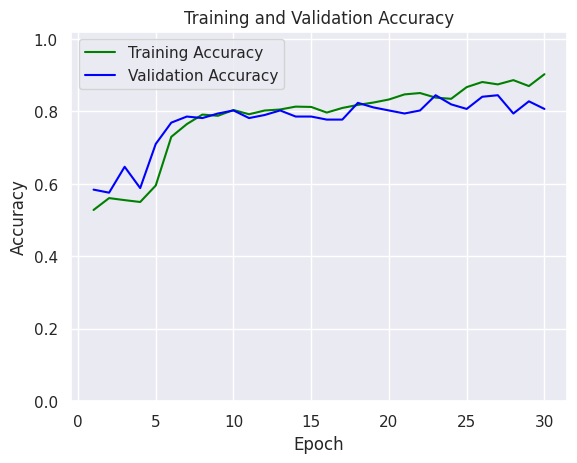

In [ ]:
#accuracy plot
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim(0,1.02)
plt.show()

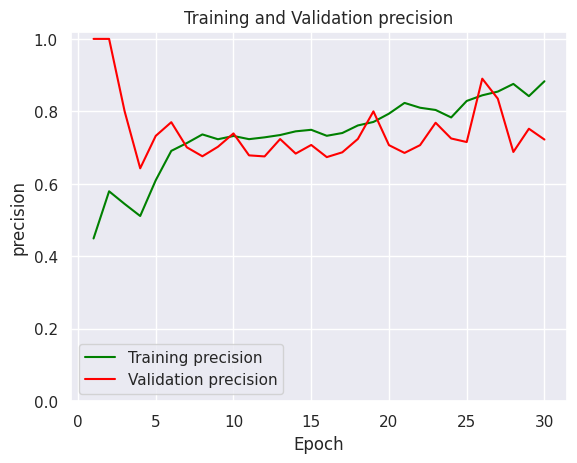

In [ ]:
plt.figure()
#loss plot
plt.plot(epochs, precision, color='green', label='Training precision')
plt.plot(epochs, val_precision, color='red', label='Validation precision')
plt.title('Training and Validation precision')
plt.xlabel('Epoch')
plt.ylabel('precision')
plt.legend()
plt.ylim(0,1.02)
plt.show()

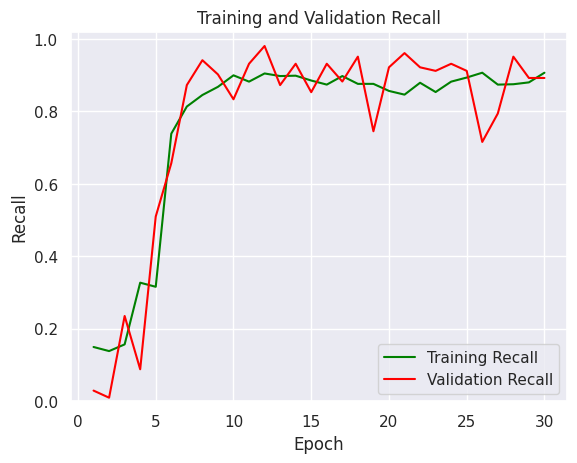

In [ ]:
plt.figure()
#loss plot
plt.plot(epochs, recall, color='green', label='Training Recall')
plt.plot(epochs, val_recall, color='red', label='Validation Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.ylim(0,1.02)
plt.show()

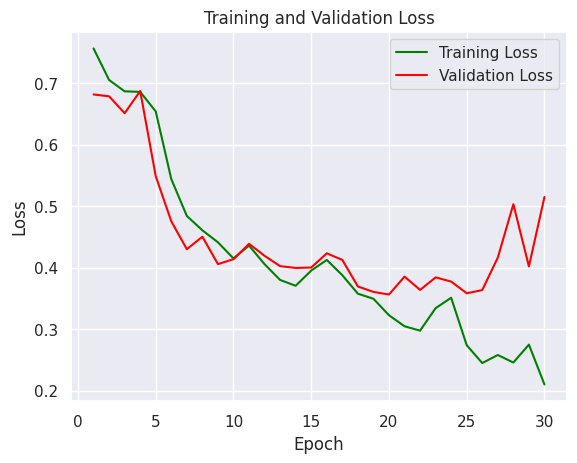

In [ ]:
plt.figure()
#loss plot
plt.plot(epochs, loss, color='green', label='Training Loss')
plt.plot(epochs, val_loss, color='red', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the model
model_evaluate = model.evaluate(X_test, y_test)
print("Loss     : ",model_evaluate[0])
print("Accuracy : ",model_evaluate[1])
print("Precision  : ",model_evaluate[2])
print("Recall : ",model_evaluate[3])

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.8150 - loss: 1.0984 - precision: 0.7239 - recall: 0.9331
Loss     :  1.0684008598327637
Accuracy :  0.8371211886405945
Precision  :  0.7549669146537781
Recall :  0.949999988079071


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
Classification report : 
               precision    recall  f1-score   support

      benign       0.95      0.74      0.83       144
   malignant       0.75      0.95      0.84       120

    accuracy                           0.84       264
   macro avg       0.85      0.85      0.84       264
weighted avg       0.86      0.84      0.84       264

Confusion matrix : 



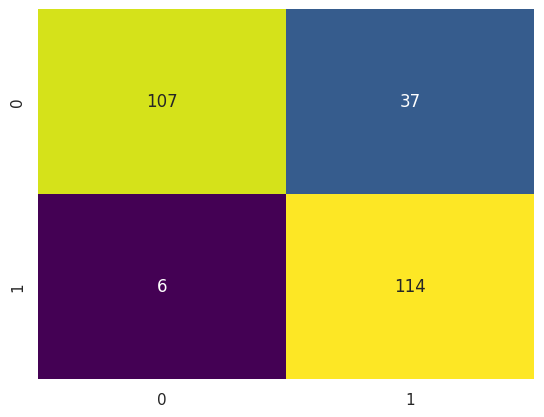

Normalized confusion matrix : 



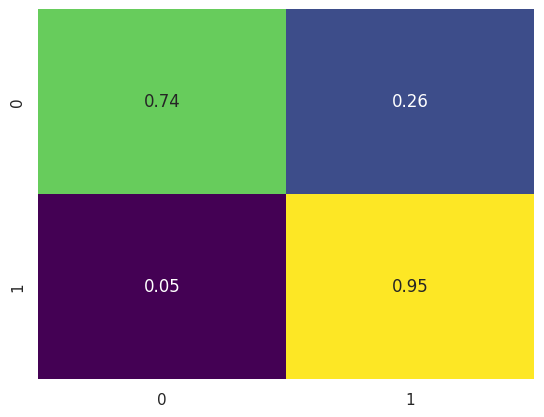

In [ ]:
# Confusion Matrix
y_pred = np.round(model.predict(X_test))
#y_pred = (model.predict(X_test) > 0.5).astype("int32").tolist()

class_names = ["benign", "malignant"]

# Compute classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification report : \n",classification_report(y_test, y_pred, target_names = class_names))

# Function to draw confusion matrix
import seaborn as sns
def draw_confusion_matrix(true, preds, normalize=None):
    # Compute confusion matrix
    conf_matx = confusion_matrix(true, preds, normalize = normalize)
    conf_matx = np.round(conf_matx, 2)
    # print(conf_matx)

    # plt.subplots(figsize=(14,8))
    sns.heatmap(conf_matx, annot=True, annot_kws={"size": 12},fmt="g", cbar=False, cmap="viridis")
    plt.show()

print("Confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred)

print("Normalized confusion matrix : \n")
draw_confusion_matrix(y_test, y_pred, "true")



In [ ]:
model.save("/content/drive/MyDrive/models/Cancer30epoch.h5")

In [ ]:
model = keras.models.load_model("/content/drive/MyDrive/models/Cancer30epoch.h5")

# **Inference**

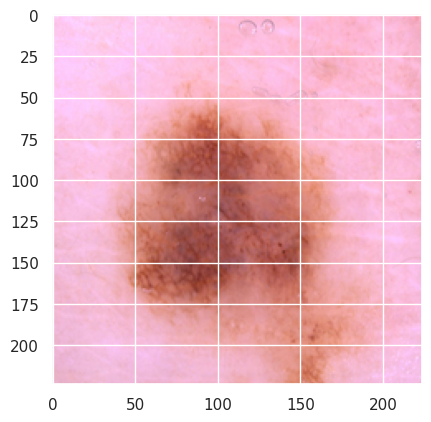

(1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction probability for malignant: 0.44797137
Prediction class: benign
Risk Level: Low Risk


In [ ]:
import cv2

img = cv2.imread("/content/drive/MyDrive/SkinLesion/test/benign/10.jpg")
H,W,C = 224,224,3
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (H, W))
img = np.array(img)
img = img.astype("float32")
img = img / 255.0

plt.imshow(img)
plt.show()

img = img.reshape(1,H,W,C)
print(img.shape)

prediction_proba = model.predict(img).flatten()[0]
prediction_class = np.round(prediction_proba)

class_names = ["benign", "malignant"]

print("Prediction probability for malignant:", prediction_proba)
print("Prediction class:", class_names[int(prediction_class)])

# Determine risk level based on the threshold (0.5)
risk_level = "High Risk" if prediction_proba > 0.5 else "Low Risk"
print("Risk Level:", risk_level)

In [ ]:
print(prediction_proba)

0.49968144
